In [57]:
import pandas as pd 
import numpy as np 
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
%cd "C:\Users\amatk\OneDrive\Dokumenty\2_Tuebingen\SoSe_26\Speaker-Recognition-using-ResNet-Embeddings\preds"

C:\Users\amatk\OneDrive\Dokumenty\2_Tuebingen\SoSe_26\Speaker-Recognition-using-ResNet-Embeddings\preds


In [25]:
NUM_CLASSES = 50

## Define Functions

In [ ]:
def show_highest_confusion(num_classes, cm, n):
    errors = []
    
    for true_class in range(num_classes):
        for pred_class in range(num_classes):
            if true_class != pred_class:
                errors.append(
                    (
                        true_class,
                        pred_class,
                        cm[true_class, pred_class]
                    )
                )
    errors = sorted(errors, key = lambda x: x[2], reverse=True)

    print("Largest confusions: ")
    for t, p, n in errors[:n]:
        print(f"{t} -> {p}: {n}")

In [ ]:
def display_highest_confidence(df):
    df.sort_values(by="Confidence", ascending=False).head(10))

In [ ]:
def show_highest_confidence_false_pred(df):
    wrong = df[~df.Correct]
    print(wrong.sort_values(by="Confidence", ascending=False).head(10))


In [ ]:
def avg_correct_pred_per_class(df):
    per_class = df.groupby("True")["Correct"].mean().sort_values()
    
    per_class.name = "mean"

    return per_class

In [17]:
def plot_confidence_histogram(df):
    plt.hist(df[df.Correct]["Confidence"],
         bins=30,
         alpha=0.6,
         label="Correct")

    plt.hist(df[~df.Correct]["Confidence"],
         bins=30,
         alpha=0.6,
         label="Wrong")

    plt.legend()
    plt.xlabel("Prediction confidence")
    plt.ylabel("Count")
    plt.show()

## Load Datasets

In [22]:
data_1s = pd.read_csv("predictions_1sec.csv")
data_2s = pd.read_csv("predictions_2sec.csv")
data_4s = pd.read_csv("predictions_4sec.csv")
data_c = pd.read_csv("predictions_contr.csv")

In [23]:
labels_4s = list(data_4s["True"])
preds_4s = list(data_4s["Pred"])

labels_2s = list(data_2s["True"])
preds_2s = list(data_2s["Pred"])

labels_1s = list(data_1s["True"])
preds_1s = list(data_1s["Pred"])

labels_c = list(data_c["True"])
preds_c = list(data_c["Pred"])

In [24]:
cm_4s = confusion_matrix(labels_4s, preds_4s, normalize="true")

cm_2s = confusion_matrix(labels_2s, preds_2s, normalize="true")

cm_1s = confusion_matrix(labels_1s, preds_1s, normalize="true")

cm_c = confusion_matrix(labels_c, preds_c, normalize="true")

In [ ]:
# TODO: plot the most common errors 
# TODO: plot show_avg_correct_pred_per_class across the different models

In [52]:
avg_1 = avg_correct_pred_per_class(data_1s)
avg_2 = avg_correct_pred_per_class(data_2s)
avg_4 = avg_correct_pred_per_class(data_4s)
avg_c = avg_correct_pred_per_class(data_c)

In [73]:
df_averages = pd.concat(
    {
        "Model 1s": avg_1, 
        "Model 2s": avg_2, 
        "Model 4s": avg_4, 
        "Model c": avg_c
    }, 
    axis=1
)

In [75]:
# Convert index (class labels) to a column, then melt the columns into rows
df_long = df_averages.reset_index().melt(
    id_vars="True", 
    var_name="Model",  # Column name for the models
    value_name="Average_Confidence",  # Column name for the values
)

In [71]:
df_long

,True,Model,Average_Confidence
0,5,Model 1s,0.549020
1,21,Model 1s,0.568182
2,18,Model 1s,0.592593
3,23,Model 1s,0.611111
4,8,Model 1s,0.613636
...,...,...,...
195,42,Model c,0.945946
196,3,Model c,0.860465
197,44,Model c,1.000000
198,16,Model c,0.981132


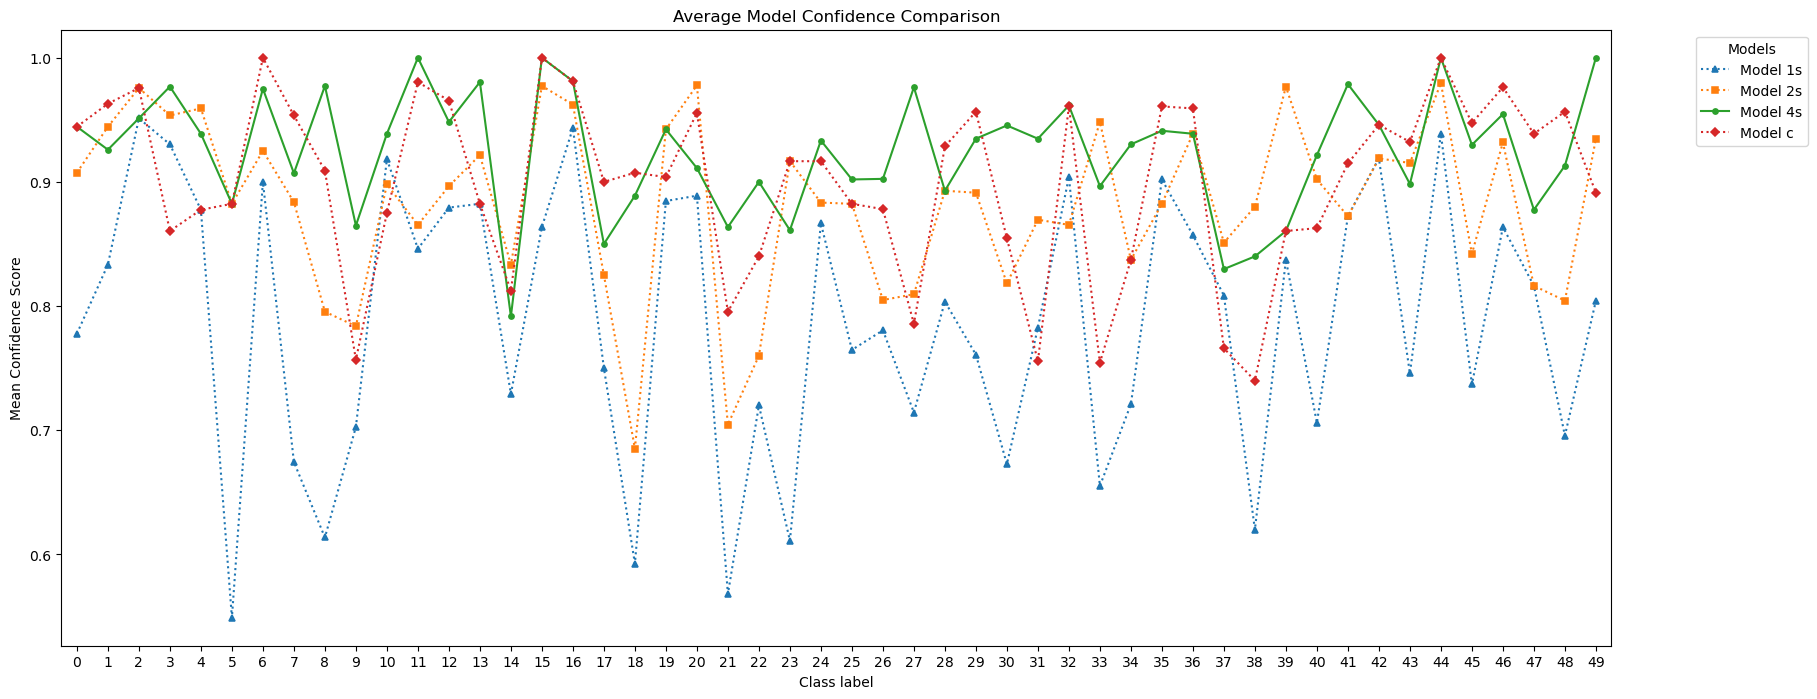

In [96]:
plt.figure(figsize=(20,8))
sns.pointplot(
    data = df_long, 
    x="True",
    y="Average_Confidence",
    hue = "Model", 
    markers=["^", "s", "o", "D"], # Different shapes per model
    linestyles=[":", ":", "-", ":"], 
    lw = 1.5
)

plt.ylabel("Mean Confidence Score")
plt.xlabel("Class label")
plt.title("Average Model Confidence Comparison")
plt.legend(title="Models", bbox_to_anchor=(1.05, 1), loc = 'upper left')
# plt.tight_layout()
plt.show()